# 01 — A Guy Falls

Boring on purpose. Before any allomancy, the engine has to get plain gravity right,
and we have to *prove* it rather than eyeball it.

The engine (`sim/`) is a side-view 2D world: x is horizontal, y is up, the ground is
the line y = 0. It advances on a fixed tick (1/240 s) with no randomness anywhere, so
the same setup always produces exactly the same run.

**The test:** drop an 80 kg guy from 20 m. Physics says his height follows
$y(t) = y_0 - \tfrac{1}{2} g t^2$ and he lands at $t = \sqrt{2 (y_0 - r) / g}$,
where $r$ is his body radius (his center rests at $r$ above the ground line).
If the simulated curve sits on the analytic curve and the landing times agree,
the engine's gravity and ground contact are trustworthy.

In [1]:
import sys
sys.path.insert(0, "..")  # the sim package lives one folder up

import math
import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, GRAVITY_M_PER_S2

In [2]:
world = World()
guy = world.add_body(Body("guy", mass_kg=80, position=(0, 20)))
world.run(3.0)

data = world.history.body("guy")
landed_tick = np.argmax(data["on_ground"])
simulated_landing = data["t"][landed_tick]
analytic_landing = math.sqrt(2 * (20 - guy.radius_m) / GRAVITY_M_PER_S2)

print(f"simulated landing: {simulated_landing:.4f} s")
print(f"analytic landing:  {analytic_landing:.4f} s")
print(f"difference:        {abs(simulated_landing - analytic_landing) * 1000:.1f} ms")

simulated landing: 2.0042 s
analytic landing:  2.0041 s
difference:        0.1 ms


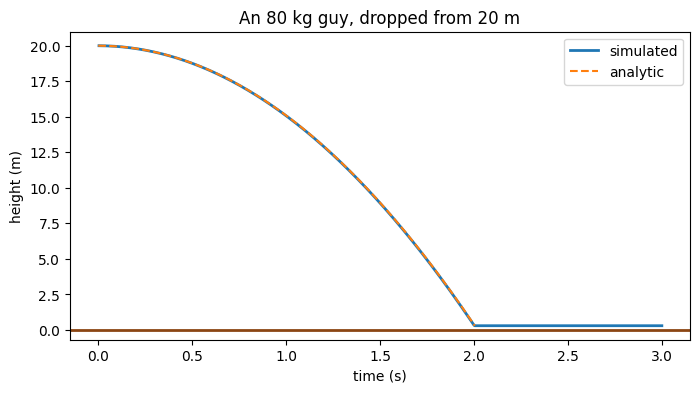

In [3]:
figure, ax = plt.subplots(figsize=(8, 4))

ax.plot(data["t"], data["y"], label="simulated", linewidth=2)

analytic_time = np.linspace(0, analytic_landing, 200)
analytic_height = 20 - 0.5 * GRAVITY_M_PER_S2 * analytic_time**2
ax.plot(analytic_time, analytic_height, "--", label="analytic", linewidth=1.5)

ax.axhline(0, color="saddlebrown", linewidth=2)
ax.set_xlabel("time (s)")
ax.set_ylabel("height (m)")
ax.set_title("An 80 kg guy, dropped from 20 m")
ax.legend()
plt.show()

## What to look for

The solid and dashed curves should be indistinguishable until the floor, and the
landing-time difference should be a few milliseconds at most (one tick is ~4.2 ms,
so we can't do better than tick resolution).

If that holds: gravity, integration, and ground contact are verified, and notebook 02
can start burning steel on top of them.